<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week10_Latihan1_Data_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
#Load dataset iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [3]:
# Tampilkan data
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
# K-Means dengan 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


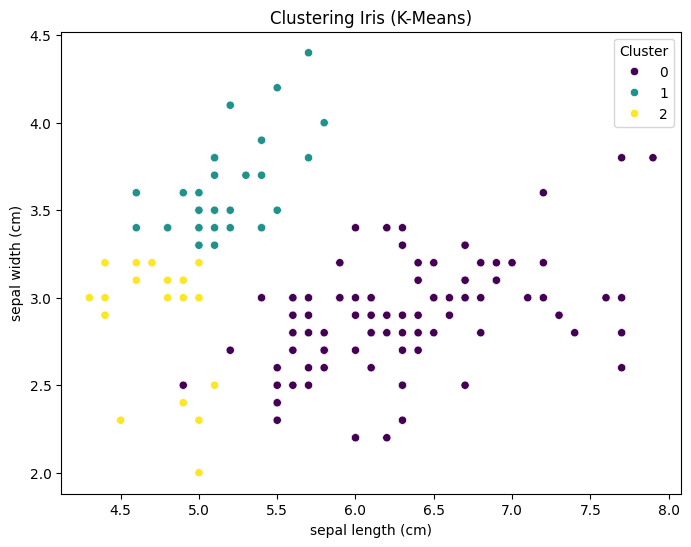

In [6]:
# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Clustering Iris (K-Means)")
plt.show()


Silhouette Score: 0.480
Inertia (k=3): 191.025


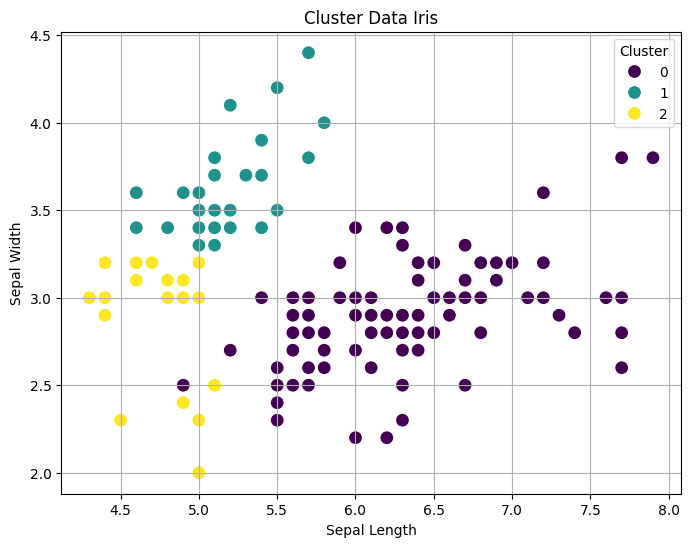

In [7]:
from sklearn.metrics import silhouette_score

# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# Inertia
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Visualisasi (pakai fitur Iris)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Cluster Data Iris')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()